# Fixed income: versioned curve marks, restatements, carry & rolldown

A rates desk's core dataset is small but unforgiving. One par curve per mark
date, and every number on it feeds risk, P&L and client marks.

The natural layout here is *long format*, `(ts, tenor_years, yield_pct)`, with
one commit per mark date. That buys three things at once: SQL pivots for any
curve analytics, a version per EOD mark set, which is the audit trail
regulators actually ask about, and previewable restatements when a bad
contributor slips through.

In this recipe we:

1. store 250 business days of curves, including one fat-fingered 10y mark we
   plant deliberately,
2. run slope and curvature analytics,
3. *find* the bad mark in SQL and restate it with `plan_replace_range`,
4. prove the pre-restatement view is still queryable forever.

## Terms used here

| term        | meaning |
| ----------- | --- |
| yield curve | interest rate plotted against maturity |
| par curve   | the curve quoted as the coupon that prices a bond at 100 |
| tenor       | the maturity point on the curve, e.g. 2y or 10y |
| long format | one row per `(date, tenor, yield)` rather than one column per tenor |
| slope       | a long tenor's yield minus a short one's, e.g. 10y minus 2y |
| curvature   | the middle of the curve against its ends, also called a butterfly |
| carry       | what a position earns from time passing, if the curve does not move |
| rolldown    | the gain from a bond aging into a lower point on an upward sloping curve |
| mark        | an official price for a position, set once per day or more often |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, sql_expr, when
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_curves"), create=True)

## 1. The data

`cu.make_yield_curves` gives daily par yield curves with Nelson-Siegel
dynamics, in long format: one row per tenor per mark date, ten tenors from 3
months to 30 years.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | mark date |
| `tenor_years` | `float64` | tenor in years: 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30 |
| `yield_pct` | `float64` | par yield, percent |

In [2]:
curves = cu.make_yield_curves(days=250)
clean_df = curves.to_pandas()
print(f"{len(clean_df):,} rows x {clean_df.shape[1]} columns, "
      f"{clean_df['ts'].nunique()} mark dates")
clean_df.head()

2,500 rows x 3 columns, 250 mark dates


,ts,tenor_years,yield_pct
0,2025-07-01 21:00:00+00:00,0.25,3.4770
1,2025-07-01 21:00:00+00:00,0.50,3.4710
2,2025-07-01 21:00:00+00:00,1.00,3.4750
3,2025-07-01 21:00:00+00:00,2.00,3.5231
4,2025-07-01 21:00:00+00:00,3.00,3.5945


Now we plant the incident. On mark date #120 the 10y prints 25bp too high, as
a stale contributor would. This is what actually lands in the database.

In [3]:
mark_dates = clean_df["ts"].unique()
feed_df = clean_df.copy()
bad_date = pd.Timestamp(mark_dates[120])
bad_mask = (feed_df["ts"] == bad_date) & (feed_df["tenor_years"] == 10.0)
feed_df.loc[bad_mask, "yield_pct"] += 0.25
print(f"vendor feed: {len(feed_df):,} rows, bad 10y mark on {bad_date.date()}")

vendor feed: 2,500 rows, bad 10y mark on 2025-12-16


## 2. One mark date is one commit

Each day's ten tenors are appended together, so the commit *is* the mark set.

`versions()` then reads as the desk's marking diary: sequence, rows, and a
note naming the mark date. 250 commits in a loop is fine, because it is still
one commit per publication event, which is the batching h5i-db expects.

In [4]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("tenor_years", pa.float64()),
        pa.field("yield_pct", pa.float64()),
    ]
)
db.create_table("curves", schema, time_column="ts", sort_key=["ts", "tenor_years"])

for day_ts, day_rows in feed_df.groupby("ts"):
    db.append("curves", pa.Table.from_pandas(day_rows, schema=schema, preserve_index=False),
              note=f"EOD marks {day_ts.date()}")

[
    {k: v[k] for k in ("sequence", "op", "rows", "note") if k in v}
    for v in db.versions("curves")[-3:]
]

[{'sequence': 248,
  'op': 'append',
  'rows': 2480,
  'note': 'EOD marks 2026-06-11'},
 {'sequence': 249,
  'op': 'append',
  'rows': 2490,
  'note': 'EOD marks 2026-06-12'},
 {'sequence': 250,
  'op': 'append',
  'rows': 2500,
  'note': 'EOD marks 2026-06-15'}]

## 3. Curve analytics as SQL pivots

Long format pivots cleanly with conditional aggregation: one row per mark
date, one column per benchmark tenor.

From there the desk's standing time series are arithmetic. The 2s10s slope,
the 2s5s10s butterfly for curvature, and a naive term-structure premium proxy
of 10y minus 3m. A real term premium needs an expectations model; this is just
the long-slope observable.

In [5]:
# Long-to-wide by conditional aggregation. As a dict of tenors it is one
# definition instead of five near-identical CASE arms - add a tenor by adding
# an entry.
KEY_TENORS = {"y3m": 0.25, "y2": 2, "y5": 5, "y10": 10, "y30": 30}

key_rates = (
    db.table("curves")
    .group_by("ts")
    .agg(**{
        name: when(col("tenor_years") == t).then(col("yield_pct")).max()
        for name, t in KEY_TENORS.items()
    })
    .sort("ts")
    .to_pandas()
)
key_rates["s2s10"] = key_rates["y10"] - key_rates["y2"]
key_rates["fly_2_5_10"] = 2 * key_rates["y5"] - key_rates["y2"] - key_rates["y10"]
key_rates["slope_proxy"] = key_rates["y10"] - key_rates["y3m"]
num_cols = key_rates.columns.drop("ts")
key_rates.tail(3).round(dict.fromkeys(num_cols, 4))

,ts,y3m,y2,y5,y10,y30,s2s10,fly_2_5_10,slope_proxy
247,2026-06-11 21:00:00+00:00,3.4961,3.1330,3.0375,3.0978,3.1899,-0.0352,-0.1558,-0.3983
248,2026-06-12 21:00:00+00:00,3.5295,3.1562,3.0431,3.0874,3.1652,-0.0688,-0.1574,-0.4421
249,2026-06-15 21:00:00+00:00,3.5064,3.1472,3.0428,3.0906,3.1704,-0.0566,-0.1522,-0.4158


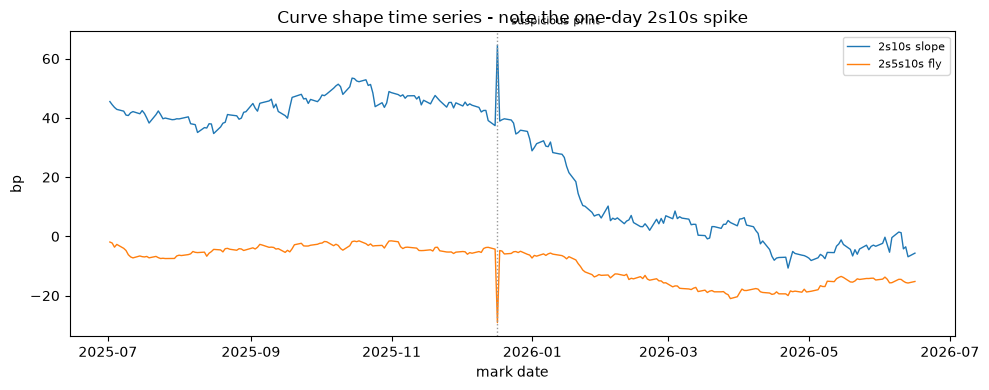

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(key_rates["ts"], 100 * key_rates["s2s10"], lw=1.0, label="2s10s slope")
ax.plot(key_rates["ts"], 100 * key_rates["fly_2_5_10"], lw=1.0, label="2s5s10s fly")
ax.axvline(bad_date, color="0.6", ls=":", lw=1)
ax.annotate("suspicious print", xy=(bad_date, 100 * key_rates.loc[key_rates["ts"] == bad_date, "s2s10"].iloc[0]),
            xytext=(10, 15), textcoords="offset points", fontsize=8)
ax.set_title("Curve shape time series - note the one-day 2s10s spike")
ax.set_xlabel("mark date")
ax.set_ylabel("bp")
ax.legend(fontsize=8)
fig.tight_layout()

## 4. Find the bad mark with a window function

A stale contributor shows up as a one-day round trip: a large day-over-day
change followed by its reversal at the same tenor.

Ranking |Δyield| across all (tenor, date) pairs surfaces it immediately.

In [7]:
PREV_Y = sql_expr("lag(yield_pct)").over(partition_by="tenor_years", order_by="ts")

(
    db.table("curves")
    .with_columns(d1=col("yield_pct") - PREV_Y)
    .filter(col("d1").is_not_null())
    .select(
        "ts", "tenor_years",
        yield_pct=col("yield_pct").round(4),
        chg_bp=(100 * col("d1")).round(1),
        abs_move=col("d1").abs(),
    )
    .sort("abs_move", descending=True)
    .limit(4)
    .select("ts", "tenor_years", "yield_pct", "chg_bp")
    .to_pandas()
)

,ts,tenor_years,yield_pct,chg_bp
0,2025-12-17 21:00:00+00:00,10.00,3.3320,-26.5
1,2025-12-16 21:00:00+00:00,10.00,3.5973,23.8
2,2026-06-05 21:00:00+00:00,0.25,3.4722,-18.8
3,2026-06-05 21:00:00+00:00,0.50,3.3898,-18.7


The top two rows are the same tenor on consecutive dates with opposite signs.
That is the signature of a bad print, not a market move.

## 5. Restate it, with a preview, a note, and full history

`plan_replace_range` stages the correction against the bad mark date. Range
bounds are raw microseconds in `ts` units and the end bound is exclusive, so
`[day_us, day_us + 1)` captures exactly that day's ten rows, since all ten
share the same timestamp.

We inspect the summary and samples *before* anything changes, then apply with
a note. The desk never edits history. It appends a corrected version on top.

In [8]:
day_us = int(bad_date.value // 1000)
corrected = clean_df[clean_df["ts"] == bad_date]  # the true marks for that day

plan = db.plan_replace_range(
    "curves", day_us, day_us + 1,
    data=pa.Table.from_pandas(corrected, schema=schema, preserve_index=False),
    note=f"restate {bad_date.date()}: 10y stale contributor, -25bp",
)
print("summary:", plan.summary)
print("\nbefore (10y row):")
print(plan.before_sample.to_pandas().query("tenor_years == 10"))
print("\nafter (10y row):")
print(plan.after_sample.to_pandas().query("tenor_years == 10"))

summary: {'rows_before': 2500, 'rows_after': 2500, 'rows_affected': 10, 'segments_reused': 249, 'segments_added': 1, 'added_bytes': 1322, 'affected_time_range': [1765918800000000, 1765918800000001]}

before (10y row):
                         ts  tenor_years  yield_pct
7 2025-12-16 21:00:00+00:00         10.0     3.5973

after (10y row):
                         ts  tenor_years  yield_pct
7 2025-12-16 21:00:00+00:00         10.0     3.3473


In [9]:
commit = plan.apply()
print(f"applied as v{commit['sequence']} ({commit['op']})")
[
    {k: v[k] for k in ("sequence", "op", "rows", "note") if k in v}
    for v in db.versions("curves")[-2:]
]

applied as v251 (replace_range)


[{'sequence': 250,
  'op': 'append',
  'rows': 2500,
  'note': 'EOD marks 2026-06-15'},
 {'sequence': 251,
  'op': 'replace_range',
  'rows': 2500,
  'note': 'restate 2025-12-16: 10y stale contributor, -25bp'}]

## 6. Point-in-time: what did risk run on that night?

Here is the question that matters after any restatement. *Which number did
downstream consumers actually see?*

Every version is still addressable, so `h5i('curves', v)` in SQL joins the
as-marked view against the restated head in one query. Overnight risk on the
bad date ran on 4.05%, while today's books show 3.80% for the same mark
date.

In [10]:
v_pre_restate = db.versions("curves")[-2]["sequence"]  # head just before the restatement
was_y, now_y = col("yield_pct", relation="l"), col("yield_pct", relation="r")

(
    db.table("curves", version=v_pre_restate)
    .join(db.table("curves"), on=["ts", "tenor_years"])
    .filter(
        col("ts", relation="l") == pd.Timestamp(day_us, unit="us", tz="UTC").isoformat(),
        col("tenor_years", relation="l").is_in([2, 5, 10, 30]),
    )
    .select(
        tenor_years=col("tenor_years", relation="l"),
        as_marked_that_night=was_y.round(4),
        restated=now_y.round(4),
        diff_bp=(100 * (now_y - was_y)).round(1),
    )
    .sort("tenor_years")
    .to_pandas()
)

,tenor_years,as_marked_that_night,restated,diff_bp
0,2.0,2.9520,2.9520,0.0
1,5.0,3.1291,3.1291,0.0
2,10.0,3.5973,3.3473,-25.0
3,30.0,3.5568,3.5568,0.0


## 7. Carry and rolldown from the latest curve

Standard unchanged-curve arithmetic for a 5y position over a 1y horizon,
interpolating the stored tenors.

**Rolldown** is the yield pickup from aging 5y to 4y on today's curve.
**Carry** is the yield over 3m funding, which is negative here because this
simulated curve ends the year inverted at the front.

Both are yield-space approximations; multiply by duration for price space.
Fine for a relative-value screen, not for a P&L forecast.

In [11]:
# No verb for a scalar subquery: resolve the latest mark date, then filter.
latest_ts = db.table("curves").select(m=col("ts").max()).to_pandas()["m"][0]

latest = (
    db.table("curves")
    .filter(col("ts") == latest_ts.isoformat())
    .select("tenor_years", "yield_pct")
    .sort("tenor_years")
    .to_pandas()
)

tenors, ylds = latest["tenor_years"].values, latest["yield_pct"].values
y = lambda t: float(np.interp(t, tenors, ylds))

rolldown_bp = 100 * (y(5) - y(4))
carry_bp = 100 * (y(5) - y(0.25))
dur_4y = 3.7  # rough modified duration of the aged position
print(f"5y yield {y(5):.3f}%, 4y yield {y(4):.3f}%, 3m funding {y(0.25):.3f}%")
print(f"rolldown (1y horizon): {rolldown_bp:+.1f} bp  (~{rolldown_bp * dur_4y / 100:+.2f}% price)")
print(f"carry over funding:    {carry_bp:+.1f} bp")
print(f"carry + roll:          {carry_bp + rolldown_bp:+.1f} bp per year, curve unchanged")

5y yield 3.043%, 4y yield 3.060%, 3m funding 3.506%
rolldown (1y horizon): -1.7 bp  (~-0.06% price)
carry over funding:    -46.4 bp
carry + roll:          -48.0 bp per year, curve unchanged


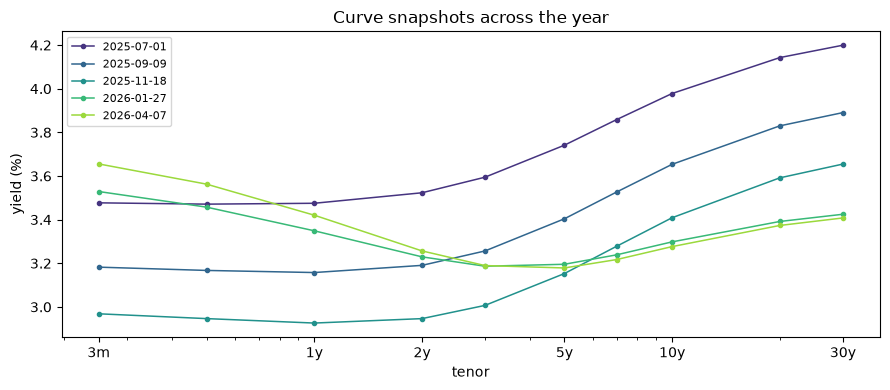

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
show_dates = mark_dates[:: len(mark_dates) // 5][:6]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(show_dates)))
for d, c in zip(show_dates, colors):
    g = clean_df[clean_df["ts"] == d]
    ax.plot(g["tenor_years"], g["yield_pct"], marker="o", ms=3, lw=1.1,
            color=c, label=str(pd.Timestamp(d).date()))
ax.set_xscale("log")
ax.set_xticks([0.25, 1, 2, 5, 10, 30])
ax.set_xticklabels(["3m", "1y", "2y", "5y", "10y", "30y"])
ax.set_title("Curve snapshots across the year")
ax.set_xlabel("tenor")
ax.set_ylabel("yield (%)")
ax.legend(fontsize=8)
fig.tight_layout()

## Takeaways

- Long format `(ts, tenor_years, yield_pct)` + one commit per mark date
  turns the curve history into a versioned, SQL-queryable marking diary.
- Conditional-aggregation pivots and `lag()` windows cover the standing
  analytics: slope, fly, and day-over-day outlier detection, without ever
  reshaping data outside the database.
- Restatements are `plan_replace_range`: microsecond range bounds
  (end-exclusive) select the mark date, the preview shows exactly what
  changes, and the note lands in `versions()` as the audit record.
- Point-in-time is free: `h5i('curves', v)` joined against the head answers
  "what did risk run on that night?" with provenance, not archaeology.
- Carry/rolldown and similar curve math read naturally off the stored
  tenors. The database serves marks, and pandas does the interpolation.

In [13]:
db.close()